# OrthoVision - Stage 1 Dataset EDA

**Scope.** RSNA knee MRI corpus for the 12-abnormality task (ACL, MCL, medial/lateral
meniscus, medial/lateral/PF OA, effusion, synovitis, Baker's, contusion, fracture).

**Provenance & rules.**
- Raw data under `data/raw/` is **read-only**; this notebook writes nothing into it.
- Figures are deterministic: series/slices are picked by sorted UID order, never randomly.
- DICOM coverage note: `train.csv` / `train_series.csv` describe the **full corpus**;
  the on-disk `train_series/` subset used for pixel-level views is smaller.
  Every chart states its scope explicitly.

**Prerequisite.** Header cache from `python scripts/scan_dicom_headers.py`
(headers only; no pixel data). The next cell verifies it.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path.cwd().resolve()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
sys.path.insert(0, str(PROJECT / "src"))

from orthovision.data.tabular import LABELS, load_train, load_series, label_statistics
from orthovision.data.pixels import decode_path, display_preview

RAW = PROJECT / "data" / "raw"
REPORTS = PROJECT / "outputs" / "reports"
HEADERS_CSV = REPORTS / "dicom_headers.csv"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

print("project:", PROJECT)
print("headers cache exists:", HEADERS_CSV.exists())


project: C:\Users\Aditya\OneDrive\Desktop\Projec\OrthoVision
headers cache exists: True


In [2]:
if not HEADERS_CSV.exists():
    raise RuntimeError(
        "Header cache missing. Run first:  python scripts/scan_dicom_headers.py"
    )

train = load_train(RAW / "train.csv")
series_csv = load_series(RAW / "train_series.csv")
hdr = pd.read_csv(HEADERS_CSV, dtype={"StudyInstanceUID": str, "SeriesInstanceUID": str})

series_attrs = series_csv.set_index("SeriesInstanceUID")
hdr["plane"] = hdr["SeriesInstanceUID"].map(series_attrs["Anatomical_Plane"])
hdr["fluid"] = hdr["SeriesInstanceUID"].map(series_attrs["Fluid_Sensitive"])
print(f"train studies: {len(train):,} | train series rows: {len(series_csv):,}")
print(f"header-cache files: {len(hdr):,} | on-disk series: {hdr['SeriesInstanceUID'].nunique()}")


train studies: 4,407 | train series rows: 24,371
header-cache files: 1,067 | on-disk series: 30


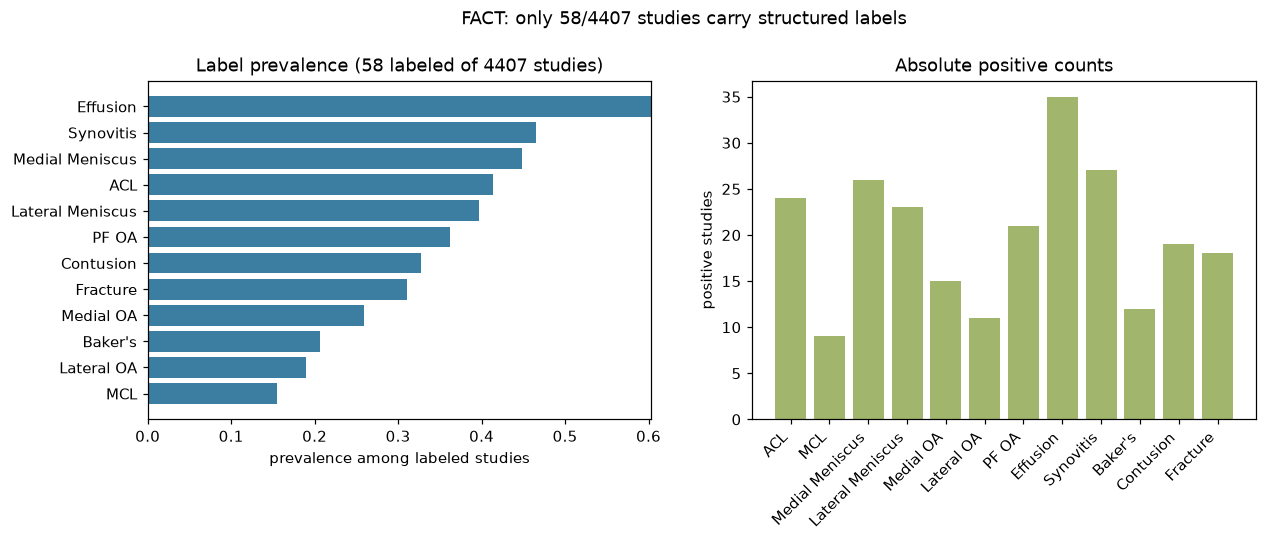

,label,positive,negative,missing,prevalence
0,ACL,24,34,4349,0.414
1,MCL,9,49,4349,0.155
2,Medial Meniscus,26,32,4349,0.448
3,Lateral Meniscus,23,35,4349,0.397
4,Medial OA,15,43,4349,0.259
5,Lateral OA,11,47,4349,0.190
6,PF OA,21,37,4349,0.362
7,Effusion,35,23,4349,0.603
8,Synovitis,27,31,4349,0.466
9,Baker's,12,46,4349,0.207


In [3]:
stats = label_statistics(train, LABELS)
labels = [s.label for s in stats]
prev = [s.prevalence_labeled for s in stats]
pos = [s.positive for s in stats]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
order = sorted(range(len(labels)), key=lambda i: prev[i])
ax[0].barh([labels[i] for i in order], [prev[i] for i in order], color="#3b7ea1")
ax[0].set_xlabel("prevalence among labeled studies")
ax[0].set_title(f"Label prevalence ({stats[0].labeled} labeled of {len(train)} studies)")
ax[0].margins(x=0)
ax[1].bar(range(len(labels)), pos, color="#a1b56c")
ax[1].set_xticks(range(len(labels)))
ax[1].set_xticklabels(labels, rotation=45, ha="right")
ax[1].set_ylabel("positive studies")
ax[1].set_title("Absolute positive counts")
fig.suptitle("FACT: only 58/4407 studies carry structured labels", y=1.04)
plt.show()

pd.DataFrame(
    {"label": labels, "positive": pos, "negative": [s.negative for s in stats],
     "missing": [s.missing for s in stats], "prevalence": np.round(prev, 3)}
)


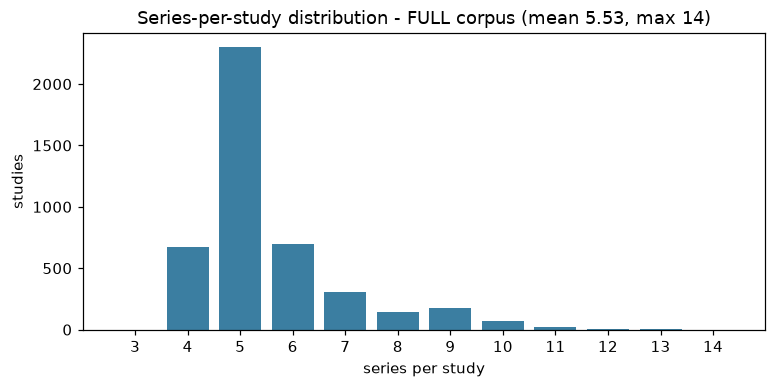

,count,mean,std,min,25%,50%,75%,max
value,4407.0,5.530066,1.393826,3.0,5.0,5.0,6.0,14.0


In [4]:
sps = series_csv.groupby("StudyInstanceUID")["SeriesInstanceUID"].nunique()

fig, ax = plt.subplots(figsize=(8, 3.5))
vals = sps.value_counts().sort_index()
ax.bar(vals.index.astype(str), vals.values, color="#3b7ea1")
ax.set_xlabel("series per study")
ax.set_ylabel("studies")
ax.set_title(f"Series-per-study distribution - FULL corpus (mean {sps.mean():.2f}, max {sps.max()})")
plt.show()

sps.describe().to_frame("value").T


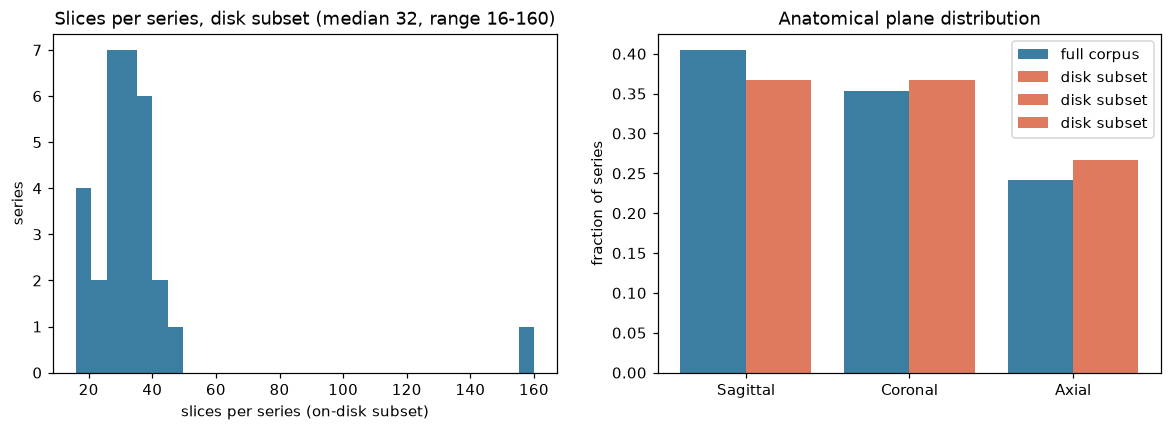

fluid/fat combos (full corpus):
Anatomical_Plane  Fluid_Sensitive  Fat_Suppression
Axial             0                0                  1179
                  1                1                  4719
Coronal           0                0                  3985
                  1                1                  4624
Sagittal          0                0                  5197
                  1                1                  4667
dtype: int64


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

counts = hdr.groupby("SeriesInstanceUID").size()
ax[0].hist(counts, bins=30, color="#3b7ea1")
ax[0].set_xlabel("slices per series (on-disk subset)")
ax[0].set_ylabel("series")
ax[0].set_title(f"Slices per series, disk subset (median {counts.median():.0f}, range {counts.min()}-{counts.max()})")

plane_full = series_csv["Anatomical_Plane"].value_counts()
plane_disk = hdr.drop_duplicates("SeriesInstanceUID")["plane"].value_counts()
x = np.arange(len(plane_full))
ax[1].bar(x - 0.2, plane_full.values / plane_full.sum(), width=0.4, label="full corpus", color="#3b7ea1")
disk_idx = [list(plane_full.index).index(p) if p in plane_full.index else None for p in plane_disk.index]
for xi, p in zip(disk_idx, plane_disk.index):
    ax[1].bar(xi + 0.2, plane_disk[p] / plane_disk.sum(), width=0.4, label="disk subset", color="#e07a5f")
ax[1].set_xticks(x)
ax[1].set_xticklabels(plane_full.index)
ax[1].set_ylabel("fraction of series")
ax[1].set_title("Anatomical plane distribution")
ax[1].legend()
plt.show()

print("fluid/fat combos (full corpus):")
print(series_csv.groupby(["Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"]).size())


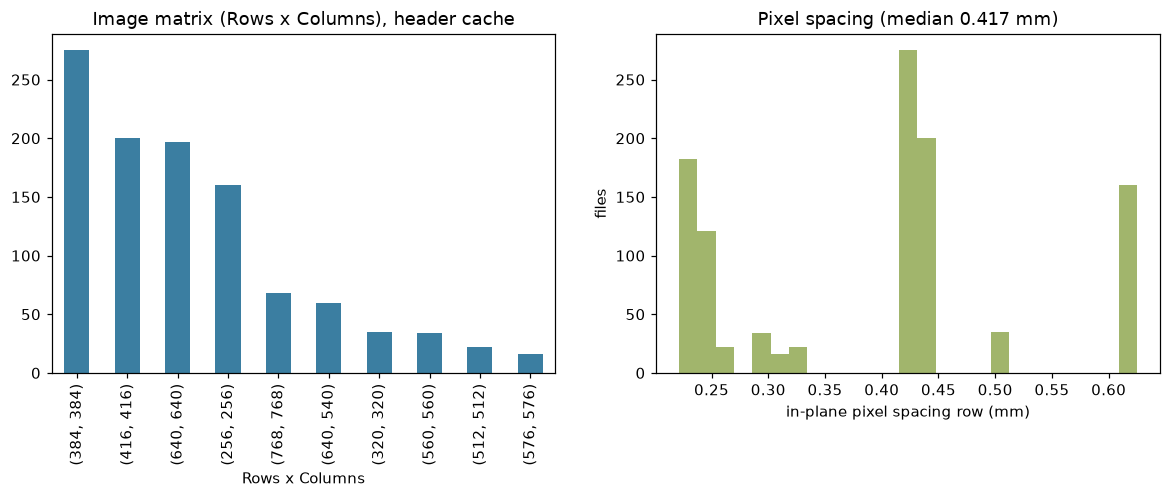

Rows,384,416,640,256,768,640,320,560,512,576
Columns,384,416,640,256,768,540,320,560,512,576
files,275,200,197,160,68,60,35,34,22,16


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

dims = hdr.groupby(["Rows", "Columns"]).size().sort_values(ascending=False)
dims.plot(kind="bar", ax=ax[0], color="#3b7ea1")
ax[0].set_title("Image matrix (Rows x Columns), header cache")
ax[0].set_xlabel("Rows x Columns")

spacing = hdr["PixelSpacing"].dropna().str.split(";").map(lambda v: float(v[0]))
ax[1].hist(spacing, bins=25, color="#a1b56c")
ax[1].set_xlabel("in-plane pixel spacing row (mm)")
ax[1].set_ylabel("files")
ax[1].set_title(f"Pixel spacing (median {spacing.median():.3f} mm)")
plt.show()

dims.to_frame("files").T


In [7]:
def parse_vec(text):
    return np.array([float(x) for x in text.split(";")])


def slice_normal(iop):
    r, c = parse_vec(iop)[:3], parse_vec(iop)[3:6]
    n = np.cross(r, c)
    return n / np.linalg.norm(n)


def series_records(series_uid):
    g = hdr[hdr["SeriesInstanceUID"] == series_uid].copy()
    n = slice_normal(g.iloc[-1]["ImageOrientationPatient"])
    g["pos"] = g["ImagePositionPatient"].map(lambda p: float(np.dot(parse_vec(p), n)))
    return g.sort_values(["pos", "InstanceNumber"]), n


def show_slice(path, ax, title):
    payload = decode_path(RAW / path)
    ax.imshow(display_preview(payload), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.axis("off")


disk_series = sorted(hdr["SeriesInstanceUID"].unique())


def first_series_with(**conds):
    for uid in disk_series:
        attrs = series_attrs.loc[uid]
        if all(attrs[k] == v for k, v in conds.items()):
            return uid
    raise LookupError(f"no disk series matches {conds}")


print("available (plane, fluid) pairs on disk:")
for uid in disk_series:
    a = series_attrs.loc[uid]
    print(f"  {a['Anatomical_Plane']:8s} fluid={a['Fluid_Sensitive']} fat={a['Fat_Suppression']}  ...{uid[-12:]}")


available (plane, fluid) pairs on disk:
  Coronal  fluid=1 fat=1  ...347467111543
  Coronal  fluid=1 fat=1  ...657887905795
  Axial    fluid=0 fat=0  ...062377650204
  Axial    fluid=1 fat=1  ...669639739403
  Sagittal fluid=0 fat=0  ...150081778633
  Sagittal fluid=1 fat=1  ...715412333772
  Coronal  fluid=1 fat=1  ...846432921455
  Axial    fluid=1 fat=1  ...949977121036
  Axial    fluid=1 fat=1  ...927426543265
  Sagittal fluid=0 fat=0  ...632489305322
  Sagittal fluid=1 fat=1  ...871973097711
  Coronal  fluid=0 fat=0  ...293168736174
  Axial    fluid=1 fat=1  ...089055309042
  Sagittal fluid=0 fat=0  ...384511165237
  Coronal  fluid=0 fat=0  ...111255984309
  Sagittal fluid=0 fat=0  ...744559693623
  Coronal  fluid=1 fat=1  ...147390476697
  Sagittal fluid=1 fat=1  ...265618938578
  Sagittal fluid=1 fat=1  ...871969421711
  Axial    fluid=0 fat=0  ...098633701528
  Sagittal fluid=0 fat=0  ...038670363546
  Coronal  fluid=0 fat=0  ...772011627242
  Coronal  fluid=0 fat=0  ...1434855

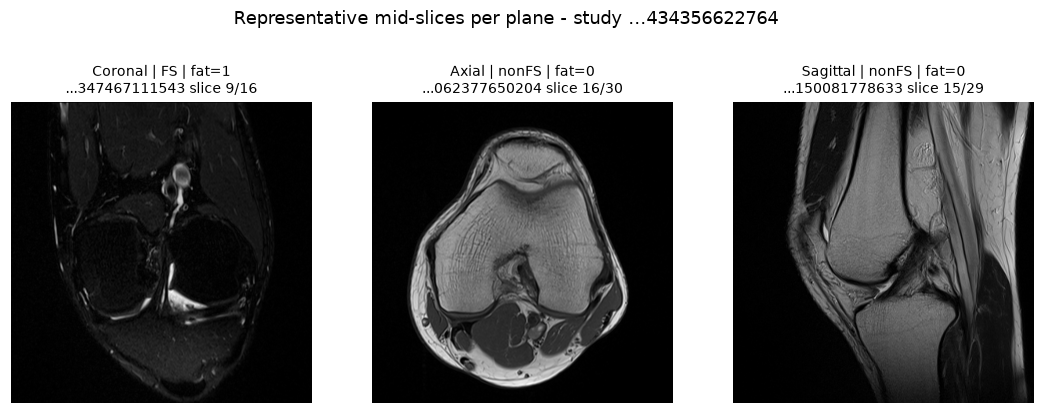

In [8]:
study_of = lambda uid: series_attrs.loc[uid, "StudyInstanceUID"]
first_study = study_of(disk_series[0])
picks = []
seen_planes = set()
for uid in disk_series:
    a = series_attrs.loc[uid]
    if study_of(uid) != first_study or a["Anatomical_Plane"] in seen_planes:
        continue
    seen_planes.add(a["Anatomical_Plane"])
    picks.append((uid, a["Anatomical_Plane"], a["Fluid_Sensitive"], a["Fat_Suppression"]))

fig, axes = plt.subplots(1, len(picks), figsize=(4 * len(picks), 4.2))
for ax, (uid, plane, fluid, fat) in zip(np.atleast_1d(axes), picks):
    recs, _ = series_records(uid)
    mid = recs.iloc[len(recs) // 2]
    tag = f"FS" if fluid == 1 else "nonFS"
    show_slice(mid["path"], ax, f"{plane} | {tag} | fat={fat}\n...{uid[-12:]} slice {len(recs)//2+1}/{len(recs)}")
fig.suptitle(f"Representative mid-slices per plane - study ...{first_study[-12:]}", y=1.02)
plt.show()


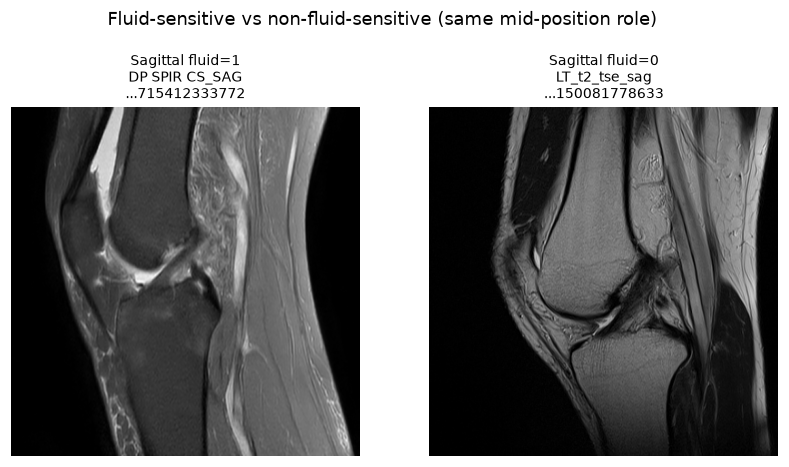

FACT: Fluid_Sensitive==Fat_Suppression everywhere in train_series.csv (every FS series is also fat-suppressed); fluid-sensitive sequences are visibly darker.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.6))
pairs = {}
for uid in disk_series:
    a = series_attrs.loc[uid]
    key = (a["Anatomical_Plane"], a["Fluid_Sensitive"])
    pairs.setdefault(key, uid)

plane = next(iter({k[0] for k in pairs if (k[0], 1) in pairs and (k[0], 0) in pairs}), None)
if plane is None:
    plane, uids = "Sagittal", [disk_series[0], disk_series[1]]
else:
    uids = [pairs[(plane, 1)], pairs[(plane, 0)]]

for ax, uid in zip(axes, uids):
    a = series_attrs.loc[uid]
    recs, _ = series_records(uid)
    mid = recs.iloc[len(recs) // 2]
    show_slice(mid["path"], ax, f"{a['Anatomical_Plane']} fluid={a['Fluid_Sensitive']}\n{mid['SeriesDescription']}\n...{uid[-12:]}")
fig.suptitle("Fluid-sensitive vs non-fluid-sensitive (same mid-position role)", y=1.03)
plt.show()

note = (
    "FACT: Fluid_Sensitive==Fat_Suppression everywhere in train_series.csv "
    "(every FS series is also fat-suppressed); fluid-sensitive sequences are visibly darker."
)
print(note)


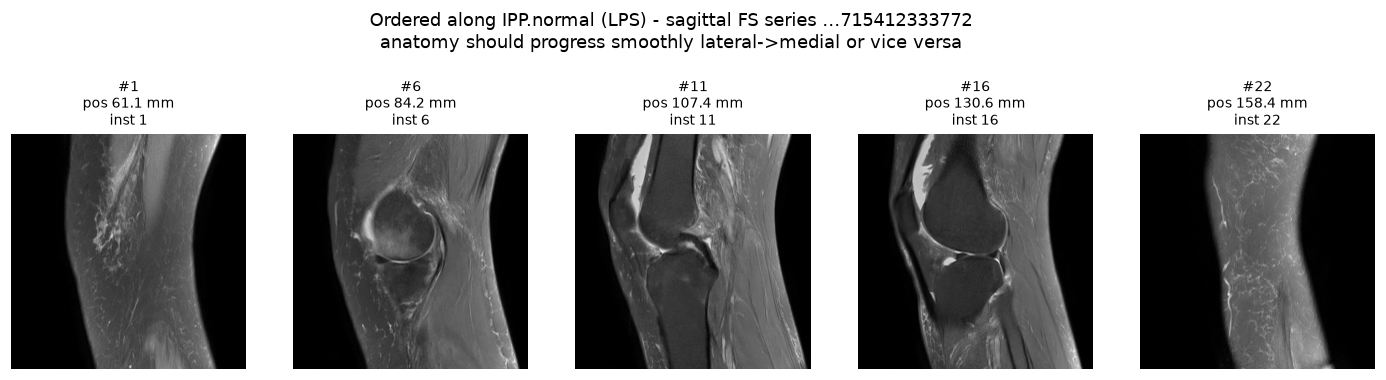

sagittal FS series ...715412333772: spearman(InstanceNumber, position) = +1.000
FACT (subset-wide): |rho| = 1.000 in all 30 series but sign flips across series (18 up / 12 down).
=> canonical anatomical order MUST come from projected position, never raw InstanceNumber.


In [10]:
uid = first_series_with(Anatomical_Plane="Sagittal", Fluid_Sensitive=1)
recs, normal = series_records(uid)
idx = np.linspace(0, len(recs) - 1, 5).astype(int)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
for ax, i in zip(axes, idx):
    row = recs.iloc[i]
    show_slice(row["path"], ax, f"#{i + 1}\npos {row['pos']:.1f} mm\ninst {row['InstanceNumber']}")
fig.suptitle(
    f"Ordered along IPP.normal (LPS) - sagittal FS series ...{uid[-12:]}\n"
    "anatomy should progress smoothly lateral->medial or vice versa",
    y=1.14,
)
plt.show()

inst = recs["InstanceNumber"].astype(float)
rho = np.corrcoef(inst.rank(), recs["pos"].rank())[0, 1]
print(f"sagittal FS series ...{uid[-12:]}: spearman(InstanceNumber, position) = {rho:+.3f}")
print("FACT (subset-wide): |rho| = 1.000 in all 30 series but sign flips across series (18 up / 12 down).")
print("=> canonical anatomical order MUST come from projected position, never raw InstanceNumber.")


## Key facts recap (all observed, see docs/DATASET_INTELLIGENCE.md)

| Area | Finding |
|------|---------|
| Labels | 58/4407 studies labeled; binary 0/1; Effusion most prevalent (0.603), MCL rarest (0.155) |
| Structure | flat layout `train_series/<SeriesInstanceUID>/<SOPInstanceUID>.dcm`; 24,371 series over 4,407 studies |
| DICOM | MR, MONOCHROME2, uint16 (12-bit stored), Explicit VR LE, no compression |
| Geometry | IOP/IPP present on 100% of subset files; CSV plane agrees with DICOM geometry 100% |
| Ordering | sort by `IPP . (IOP_row x IOP_col)`; InstanceNumber direction flips between series |
| Intensities | non-standardized; RescaleSlope>1 on some series; slope absent on ~39% of files |
